<a href="https://colab.research.google.com/github/pejuangsejati22-cmd/Aplikasi-Les-Private/blob/main/Prediksi_Depresi_Bagus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Hasil Evaluasi Model ---
Akurasi: 68.33%
Presisi: 5.13%
Recall:  66.67%


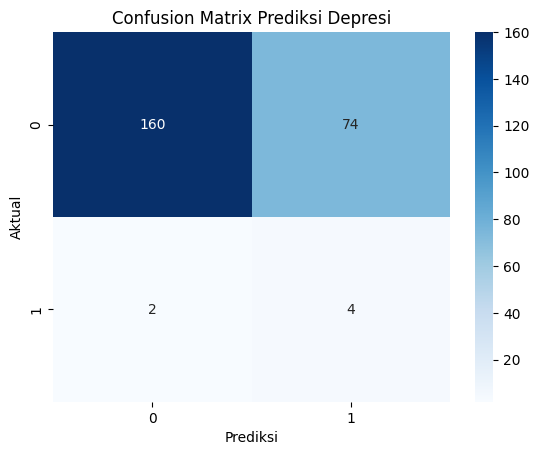

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. LOAD DATA (KDD: Data Selection) [cite: 140, 194]
# Pastikan file CSV sudah diunggah ke environment Anda
# Jika Anda mengalami FileNotFoundError, Anda mungkin perlu mengunggah file:
# from google.colab import files
# uploaded = files.upload()
# print('Uploaded files:', uploaded.keys())
# Pastikan nama file di `pd.read_csv` sesuai dengan nama file yang diunggah.
df = pd.read_csv('/content/sample_data/Teen_Mental_Health_Dataset.csv')

# 2. PRE-PROCESSING (KDD: Pre-processing) [cite: 149, 150]
# Menghapus missing values dan duplikat
df = df.dropna()
df = df.drop_duplicates()

# 3. TRANSFORMATION (KDD: Transformation) [cite: 153, 197]
# Mengubah data teks menjadi angka menggunakan Label Encoding
le = LabelEncoder()
df['platform_usage'] = le.fit_transform(df['platform_usage'])
df['social_interaction_level'] = le.fit_transform(df['social_interaction_level'])
# Label target: Depression (misal: 1 untuk Depresi, 0 untuk Normal)
df['depression_label'] = le.fit_transform(df['depression_label'])

# Memilih fitur sesuai batasan masalah penelitian
X = df[['daily_social_media_hours', 'platform_usage', 'social_interaction_level']]
y = df['depression_label']

# Split data: 80% Latih, 20% Uji [cite: 199]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. MODELLING (KDD: Data Mining) [cite: 68, 156]
model = GaussianNB()
# Melatih model menggunakan data pelatihan yang sudah diseimbangkan dengan SMOTE
model.fit(X_train_resampled, y_train_resampled)

# 5. EVALUATION (KDD: Interpretation and Evaluation) [cite: 159, 172]
y_pred = model.predict(X_test)

# Menghitung Metrik Evaluasi
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"--- Hasil Evaluasi Model ---")
print(f"Akurasi: {accuracy * 100:.2f}%")
print(f"Presisi: {precision * 100:.2f}%")
print(f"Recall:  {recall * 100:.2f}%")

# Visualisasi Confusion Matrix [cite: 173]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Prediksi Depresi')
plt.show()

In [25]:
print("\n--- Analisis Pengaruh Fitur --- ")
feature_names = X.columns

# Memeriksa parameter model (mean dan variance) untuk setiap fitur per kelas
# Kelas 0: Tidak Depresi, Kelas 1: Depresi

print("\nRata-rata (Mean) Fitur per Kelas:")
for i, feature in enumerate(feature_names):
    print(f"  {feature}:")
    print(f"    Tidak Depresi (Class 0): {model.theta_[0, i]:.4f}")
    print(f"    Depresi (Class 1): {model.theta_[1, i]:.4f}")

print("\nVariansi (Variance) Fitur per Kelas:")
for i, feature in enumerate(feature_names):
    print(f"  {feature}:")
    print(f"    Tidak Depresi (Class 0): {model.var_[0, i]:.4f}")
    print(f"    Depresi (Class 1): {model.var_[1, i]:.4f}")

# Interpretasi:
# Fitur yang menunjukkan perbedaan yang lebih besar antara rata-rata atau variansi
# antar kelas cenderung lebih berpengaruh dalam membedakan kedua kelas tersebut.


--- Analisis Pengaruh Fitur --- 

Rata-rata (Mean) Fitur per Kelas:
  daily_social_media_hours:
    Tidak Depresi (Class 0): 4.4859
    Depresi (Class 1): 6.7331
  platform_usage:
    Tidak Depresi (Class 0): 0.9947
    Depresi (Class 1): 0.6631
  social_interaction_level:
    Tidak Depresi (Class 0): 1.0406
    Depresi (Class 1): 0.8278

Variansi (Variance) Fitur per Kelas:
  daily_social_media_hours:
    Tidak Depresi (Class 0): 4.0823
    Depresi (Class 1): 0.7711
  platform_usage:
    Tidak Depresi (Class 0): 0.6620
    Depresi (Class 1): 0.4929
  social_interaction_level:
    Tidak Depresi (Class 0): 0.6529
    Depresi (Class 1): 0.6581


In [26]:
from sklearn.metrics import classification_report

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.68      0.81       234
           1       0.05      0.67      0.10         6

    accuracy                           0.68       240
   macro avg       0.52      0.68      0.45       240
weighted avg       0.96      0.68      0.79       240



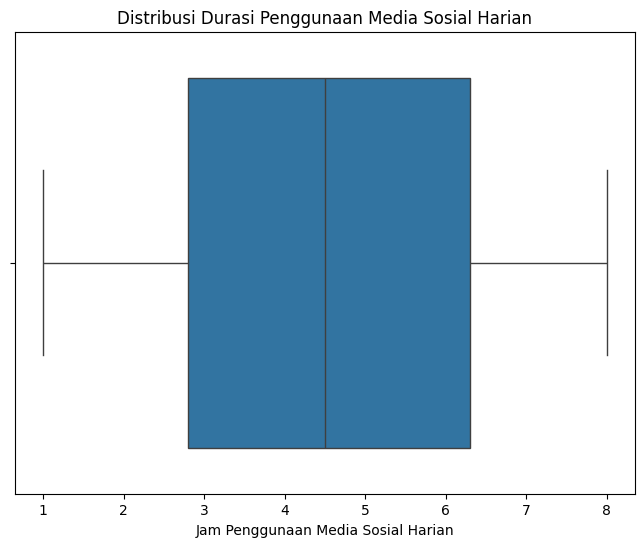

In [27]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['daily_social_media_hours'])
plt.title('Distribusi Durasi Penggunaan Media Sosial Harian')
plt.xlabel('Jam Penggunaan Media Sosial Harian')
plt.show()

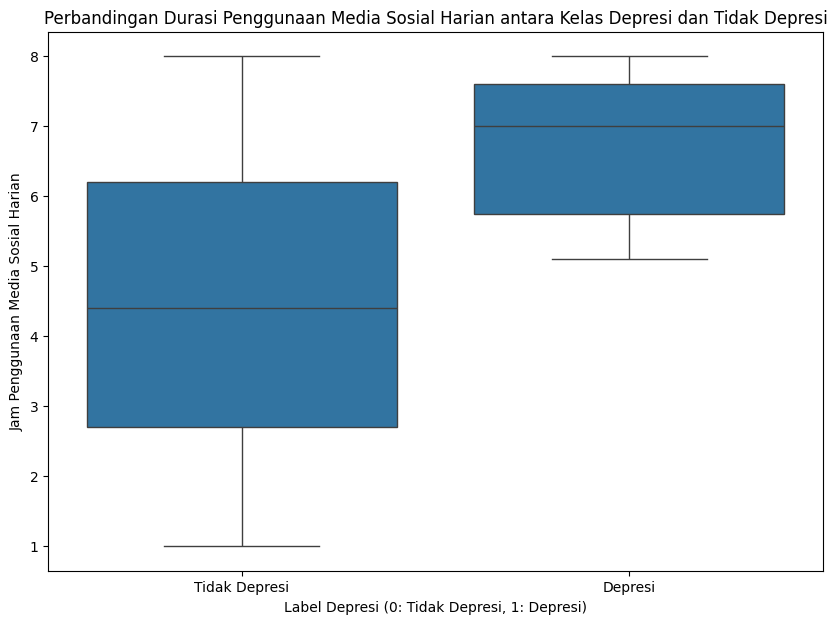

In [29]:
plt.figure(figsize=(10, 7))
sns.boxplot(x='depression_label', y='daily_social_media_hours', data=df)
plt.title('Perbandingan Durasi Penggunaan Media Sosial Harian antara Kelas Depresi dan Tidak Depresi')
plt.xlabel('Label Depresi (0: Tidak Depresi, 1: Depresi)')
plt.ylabel('Jam Penggunaan Media Sosial Harian')
plt.xticks([0, 1], ['Tidak Depresi', 'Depresi'])
plt.show()

In [23]:
from imblearn.over_sampling import SMOTE

# Terapkan SMOTE untuk menyeimbangkan kelas target pada data latih
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Distribusi kelas target setelah SMOTE:")
display(pd.Series(y_train_resampled).value_counts())

Distribusi kelas target setelah SMOTE:


,count
depression_label,
0,935
1,935


In [28]:
# 1. Menghapus spasi berlebih pada nama kolom (opsional, karena kolom data sudah dienkode)
df.columns = df.columns.str.strip()
# Menghapus spasi berlebih pada isi data (hanya berlaku untuk kolom string yang belum dienkode)
# df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# 2. Menyeragamkan huruf menjadi kecil semua (agar tidak ada duplikasi kategori)
# Baris ini dihapus karena kolom 'platform_usage' dan 'social_interaction_level' sudah dienkode menjadi angka.
# df['platform_usage'] = df['platform_usage'].str.lower()
# df['social_interaction_level'] = df['social_interaction_level'].str.lower()

# 3. Menangani Missing Values (KDD: Cleaning) [cite: 150]
# Baris ini dihapus karena sudah dilakukan di sel sebelumnya.
# df = df.dropna()

# 4. Simpan kembali file yang sudah rapi (opsional)
df.to_csv('Teen_Mental_Health_Dataset_Clean.csv', index=False)

In [19]:
print("Distribusi data target (depression_label):")
display(df['depression_label'].value_counts())

Distribusi data target (depression_label):


,count
depression_label,
0,1169
1,31
